In [1]:
import pylbsr.notebooks
import pylbsr.misc

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path
from dotmap import DotMap
from tqdm import tqdm

from scipy.stats import pearsonr

import parnet
from parnet_additional_utils import GzListDataset, ParnetModelName, load_parnet_model
from parnet.layers import LinearProjectionHead

/home/lhofer/pixi-envs/parnet--globalclip-head-6013472398032450694/envs/parnet-dev-cu12/lib/python3.10/site-packages/gin/config.py:615: FutureWarning: `NLLLoss2d` has been deprecated. Please use `NLLLoss` instead as a drop-in replacement and see https://pytorch.org/docs/main/nn.html#torch.nn.NLLLoss for more details.
  decorated_class = decorating_meta(cls.__name__, (cls,), overrides)
Seed set to 42


In [2]:
_notebook_name = "03_integrated_gradients.ipynb"
_notebook_path = f"notebooks/globalclip-head/{_notebook_name}"

pylbsr.notebooks.enable_cell_timing_metadata(show=True)
logger = pylbsr.misc.init_logger(_notebook_name)
PROJECT_DIR = pylbsr.notebooks.find_project_root_from_notebook_path(_notebook_path)
logger.info(f"Project directory: {PROJECT_DIR}")

[19:28:41] INFO - Project directory: /mnt/storage1/workspace/lhofer/parnet--globalclip-head


In [3]:
# ── GPU setup ──────────────────────────────────────────────────────────────────
pylbsr.misc.set_seed(42)

params_gpu_index = 0
device = torch.device(f"cuda:{params_gpu_index}")
torch.cuda.set_device(params_gpu_index)

if torch.cuda.is_available():
    logger.info(f"Using GPU: {torch.cuda.get_device_name(device)}")
else:
    logger.warning("No GPU available, using CPU instead.")

[19:28:44] INFO - Using GPU: NVIDIA RTX A4000


Seed set to 42
⏱ 0.18 s (00:00:00)


In [12]:
# ── Parameters ─────────────────────────────────────────────────────────────────
# Run to load the model from
EVAL_RUN = "parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50"

# Pretrained backbone this run was fine-tuned from
# or PARNET_21M_0_0 / PARNET_21M_NONE
PRETRAINED_MODEL = ParnetModelName.PARNET_7M_0_0

# Data used for this run (filtered or raw)
USE_FILTERED_DATA = True

# Integrated Gradients settings
params_n_steps: int = 50
params_n_sequences: int = None

# Data
params_seq_length: int = 600
params_num_tasks: int = 1

# ── Metamotif parameters ───────────────────────────────────────────────────────
params_sig_p = 0.05        # search significance threshold (was 0.01) — more sensitive
params_seed_size = 3       # search seed size
params_max_size = 20       # search max subsequence size
params_min_support = 20    # alignment: min k-mers to retain a motif (was 100)
params_max_motifs = 15     # alignment: max motifs to extract (was 5)

⏱ 0.00 s (00:00:00)


In [13]:
# ── Filepaths ──────────────────────────────────────────────────────────────────
_fp_cfg = yaml.safe_load((PROJECT_DIR / "config" / "filepaths.yaml").read_text())

_data_key = "data_lysate_noNHS_filtered" if USE_FILTERED_DATA else "data_lysate_noNHS"

FILEPATHS = DotMap()
FILEPATHS["data"] = Path(_fp_cfg["global_clip"][_data_key])
FILEPATHS["pretrained_model"] = Path(_fp_cfg["models"][PRETRAINED_MODEL.value])
FILEPATHS["run_dir"] = PROJECT_DIR / "results" / "globalclip-head" / "training" / EVAL_RUN
FILEPATHS["output_dir"] = FILEPATHS["run_dir"] / "integrated_gradients"
FILEPATHS["figures_dir"] = PROJECT_DIR / "results" / "globalclip-head" / "figures"

FILEPATHS["output_dir"].mkdir(parents=True, exist_ok=True)
FILEPATHS["figures_dir"].mkdir(parents=True, exist_ok=True)

logger.info(f"Run dir:    {FILEPATHS.run_dir}")
logger.info(f"Output dir: {FILEPATHS.output_dir}")

[19:52:37] INFO - Run dir:    /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50
[19:52:37] INFO - Output dir: /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients


⏱ 0.03 s (00:00:00)


In [14]:
# ── Load test dataset ──────────────────────────────────────────────────────────
test_ds = GzListDataset(
    FILEPATHS.data, split="test",
    length=params_seq_length, total_key="globalCLIP", control_key="control",
    shuffle=False, mmap=True,
)

n_sequences = len(test_ds) if params_n_sequences is None else params_n_sequences
logger.info(f"Test size: {len(test_ds)} — computing IG on {n_sequences} sequences")

Loading (mmap) globalclip_lysate_noNHS.minreads3.maxsignal1000.pt split='test'... 

[19:52:53] INFO - Test size: 4896 — computing IG on 4896 sequences


loaded 4896 samples.
⏱ 12.55 s (00:00:12)


In [15]:
# ── Load model ─────────────────────────────────────────────────────────────────
class GlobalCLIPHead(torch.nn.Module):
    def __init__(self, num_tasks=1):
        super().__init__()
        self.projection = LinearProjectionHead(num_tasks)

    def forward(self, inputs, **kwargs):
        logit = self.projection(inputs)
        logprob = logit - torch.logsumexp(logit, dim=-1, keepdim=True)
        return {
            'total': logprob,
            'mix_coeff': torch.ones(inputs.shape[0], 1, device=inputs.device),
        }

model = load_parnet_model(
    PRETRAINED_MODEL,
    FILEPATHS["pretrained_model"],
    dtype=torch.float32,
    device=device,
)

model.head = GlobalCLIPHead(num_tasks=params_num_tasks).to(device)

# initialize lazy parameters — derive hidden dim from the backbone (512 for 7M, 768 for 21M)
with torch.no_grad():
    _probe_seq = test_ds[0]["inputs"]["sequence"].unsqueeze(0).to(device)
    _backbone_out = model.body(model.stem(_probe_seq))
    _hidden_dim = _backbone_out.shape[1]
    model.head(_backbone_out)
logger.info(f"Backbone hidden dim: {_hidden_dim}")

# load fine-tuned weights
_checkpoint = torch.load(FILEPATHS["run_dir"] / "model.statedict.pt", map_location=device)
model.load_state_dict(_checkpoint["state_dict"])
model.eval()
logger.info(f"Model loaded from: {FILEPATHS.run_dir / 'model.statedict.pt'}")

/home/lhofer/pixi-envs/parnet--globalclip-head-6013472398032450694/envs/parnet-dev-cu12/lib/python3.10/site-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv1d(
[19:52:58] INFO - Backbone hidden dim: 512
[19:52:58] INFO - Model loaded from: /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/model.statedict.pt


⏱ 1.65 s (00:00:01)


In [17]:
# ── Integrated Gradients implementation ────────────────────────────────────────
def integrated_gradients(model, sequence, n_steps=50):
    """
    Compute Integrated Gradients for a single sequence.
    
    Args:
        model: fine-tuned GlobalCLIP model
        sequence: (1, 4, 600) one-hot encoded sequence tensor
        n_steps: number of interpolation steps between baseline and input
    
    Returns:
        attributions: (4, 600) attribution scores
    """
    baseline = torch.zeros_like(sequence)  # all-zeros baseline (no information)
    
    # interpolate between baseline and input: (n_steps, 1, 4, 600)
    alphas = torch.linspace(0, 1, n_steps, device=sequence.device)
    interpolated = torch.stack([
        baseline + alpha * (sequence - baseline)
        for alpha in alphas
    ])  # (n_steps, 1, 4, 600)
    interpolated = interpolated.squeeze(1)  # (n_steps, 4, 600)
    interpolated.requires_grad_(True)
    
    # forward pass on all interpolated sequences at once
    output = model(sequence=interpolated)
    target = output['total'].sum()  # scalar
    
    # compute gradients
    target.backward()
    grads = interpolated.grad  # (n_steps, 4, 600)
    
    # average gradients and scale by (input - baseline)
    avg_grads = grads.mean(0)  # (4, 600)
    attributions = avg_grads * (sequence.squeeze(0) - baseline.squeeze(0))
    
    return attributions.detach().cpu()


⏱ 0.00 s (00:00:00)


In [85]:
# ── Compute IG for all test sequences ──────────────────────────────────────────
all_attributions = []
all_sequences = []

model.eval()
for i in tqdm(range(n_sequences)):
    sample = test_ds[i]
    
    # get one-hot encoded sequence (4, 600)
    sequence = sample["inputs"]["sequence"].unsqueeze(0).to(device)  # (1, 4, 600)
    
    # compute IG
    attrs = integrated_gradients(model, sequence, n_steps=params_n_steps)  # (4, 600)
    
    all_attributions.append(attrs.numpy())
    all_sequences.append(sample["inputs"]["sequence"].numpy())

all_attributions = np.stack(all_attributions)  # (n_sequences, 4, 600)
all_sequences = np.stack(all_sequences)         # (n_sequences, 4, 600)

logger.info(f"Computed IG for {n_sequences} sequences")
logger.info(f"Attribution maps shape: {all_attributions.shape}")

100%|██████████| 4896/4896 [19:42<00:00,  4.14it/s]
[19:18:00] INFO - Computed IG for 4896 sequences
[19:18:00] INFO - Attribution maps shape: (4896, 4, 600)


⏱ 1182.63 s (00:19:42)


In [86]:
# ── Save attribution maps ──────────────────────────────────────────────────────
np.save(FILEPATHS["output_dir"] / "attributions.npy", all_attributions)
np.save(FILEPATHS["output_dir"] / "sequences.npy", all_sequences)
logger.info(f"Saved attribution maps → {FILEPATHS.output_dir}")

[19:18:16] INFO - Saved attribution maps → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients


⏱ 0.45 s (00:00:00)


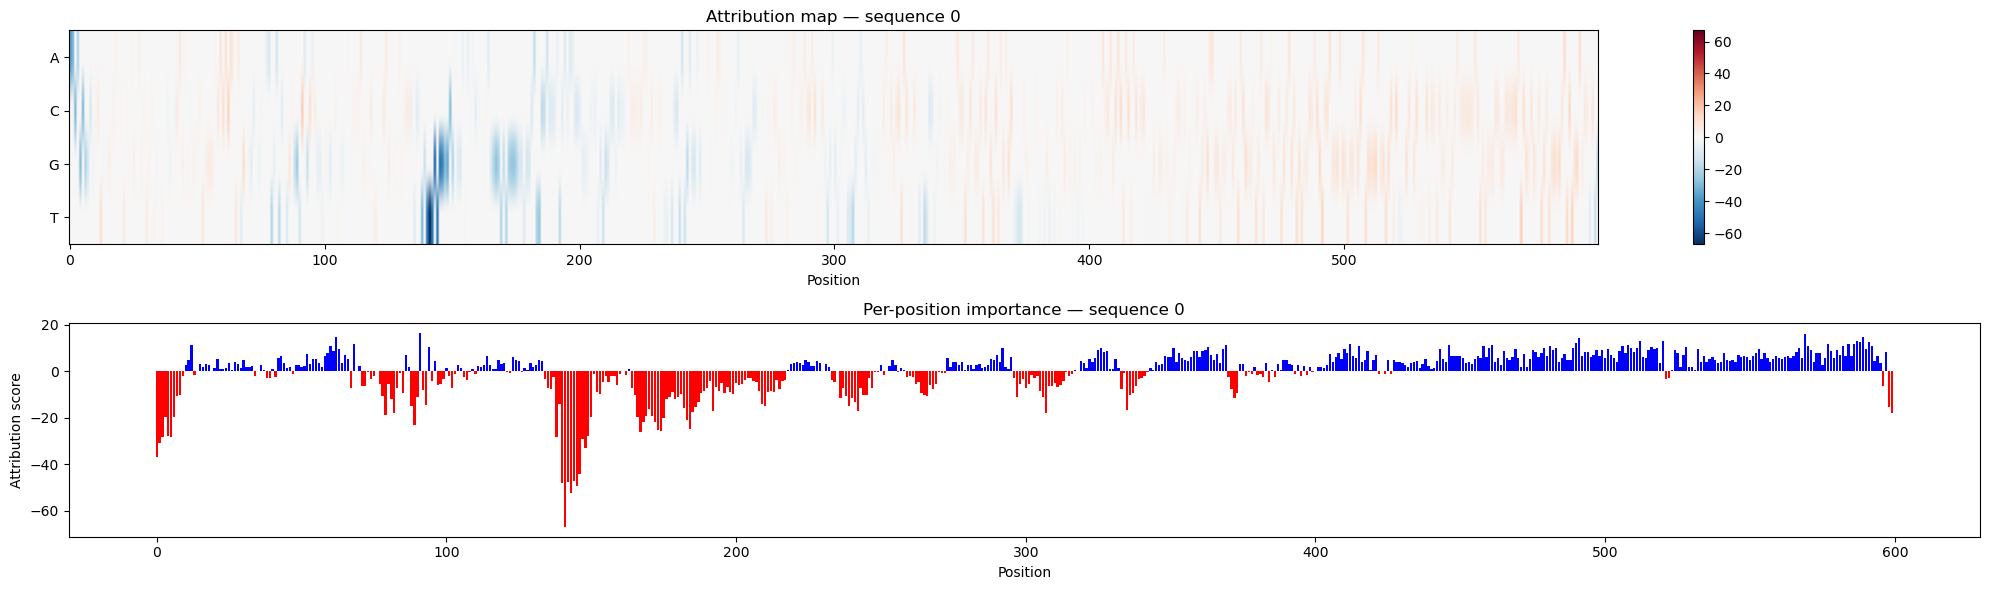

⏱ 1.18 s (00:00:01)


In [87]:
# ── Visualize single attribution map ───────────────────────────────────────────
NUCLEOTIDES = ["A", "C", "G", "T"]
SEQ_IDX = 0  # which sequence to visualize

fig, axes = plt.subplots(2, 1, figsize=(20, 6))

# ── Attribution map (4 nucleotides x 600 positions) ───────────────────────────
im = axes[0].imshow(
    all_attributions[SEQ_IDX],
    aspect="auto",
    cmap="RdBu_r",
    vmin=-np.abs(all_attributions[SEQ_IDX]).max(),
    vmax=np.abs(all_attributions[SEQ_IDX]).max(),
)
axes[0].set_yticks(range(4))
axes[0].set_yticklabels(NUCLEOTIDES)
axes[0].set_xlabel("Position")
axes[0].set_title(f"Attribution map — sequence {SEQ_IDX}")
plt.colorbar(im, ax=axes[0])

# ── Per-position importance (sum over nucleotides) ─────────────────────────────
importance = all_attributions[SEQ_IDX].sum(axis=0)  # (600,)
axes[1].bar(range(600), importance, color=["red" if v < 0 else "blue" for v in importance])
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Attribution score")
axes[1].set_title(f"Per-position importance — sequence {SEQ_IDX}")

plt.tight_layout()
plt.savefig(FILEPATHS["figures_dir"] / f"attribution_map_seq{SEQ_IDX}.png", dpi=150, bbox_inches="tight")
plt.show()

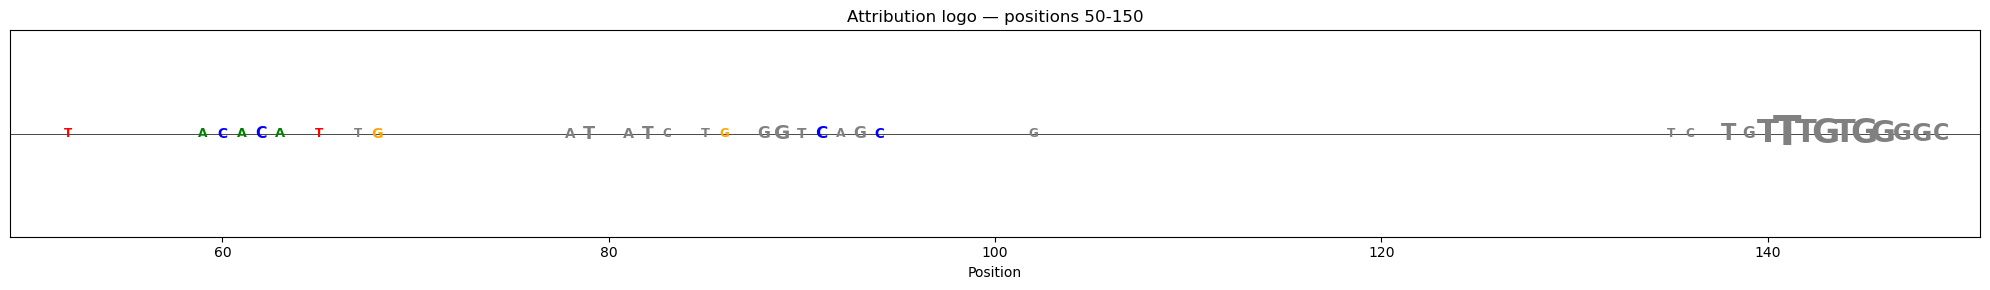

<Figure size 640x480 with 0 Axes>

⏱ 0.10 s (00:00:00)


In [89]:
def plot_attribution_logo(attributions, sequence, start=0, end=100, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(20, 3))
    
    NUCLEOTIDES = ["A", "C", "G", "T"]
    COLORS = {"A": "green", "C": "blue", "G": "orange", "T": "red"}
    
    # normalize scores to make font sizes more visible
    max_score = np.abs(attributions[:, start:end]).max()
    
    for pos in range(start, end):
        for nuc_idx, nuc in enumerate(NUCLEOTIDES):
            if sequence[nuc_idx, pos] == 0:
                continue
            score = attributions[nuc_idx, pos]
            if abs(score) < 0.1 * max_score:  # skip bottom 10%
                continue
            fontsize = 6 + (abs(score) / max_score) * 24  # scale 6-30
            color = COLORS[nuc] if score > 0 else "gray"
            ax.text(
                pos, 0, nuc,
                fontsize=fontsize,
                color=color,
                ha="center", va="center",
                fontweight="bold",
            )
    
    ax.set_xlim(start - 1, end + 1)
    ax.set_ylim(-1, 1)
    ax.set_xlabel("Position")
    ax.set_title(f"Attribution logo — positions {start}-{end}")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_yticks([])
    return ax

fig, ax = plt.subplots(figsize=(20, 3))
plot_attribution_logo(all_attributions[SEQ_IDX], all_sequences[SEQ_IDX], start=50, end=150, ax=ax)
plt.tight_layout()
plt.show()
plt.savefig(FILEPATHS["figures_dir"] / f"attribution_logo_seq{SEQ_IDX}.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
# ── Load RBP motifs ────────────────────────────────────────────────────────────
import pylbsr.bio.motifs as motifs_lib
from pylbsr.bio.motifs.motif import convert_matrix_type

MOTIFS_DIR = Path("/mnt/storage1/ml4rg26-shared/rbp_binding_motifs")
DATABASES = ["mCrossBase", "ATtRACT", "RBPmap_1.2", "oRNAment", "RBPDB"] # as a baseline

def load_motif_ppm(f):
    """Load a .transfac motif and convert to PPM for scoring."""
    with open(f) as fh:
        ms = motifs_lib.read_motifs_transfac(fh)
    if not ms:
        return None
    m = ms[0]
    
    # get matrix type from filename (e.g. K562.PCM.000.transfac)
    mt = f.stem.split(".")[1].upper()  # PCM, PPM, PWM
    m.matrix_type = mt
    
    try:
        if mt in ("PCM", "PPM"):
            m = convert_matrix_type(m, "PPM")
        else:
            return None  # skip PWM
    except Exception:
        return None
    return m

# load all motifs
all_motifs = {}  # {rbp_name: [ppm_array, ...]}
for db in DATABASES:
    preproc = MOTIFS_DIR / db / "preprocessed"
    if not preproc.exists():
        continue
    for rbp_dir in preproc.iterdir():
        if not rbp_dir.is_dir():
            continue
        rbp = rbp_dir.name
        for f in rbp_dir.glob("*.transfac"):
            m = load_motif_ppm(f)
            if m is None:
                continue
            if rbp not in all_motifs:
                all_motifs[rbp] = []
            all_motifs[rbp].append(m.matrix.to_numpy(dtype=float))

logger.info(f"Loaded motifs for {len(all_motifs)} RBPs")

[19:36:53] INFO - Loaded motifs for 430 RBPs


⏱ 54.06 s (00:00:54)


In [91]:
# ── Convert attributions to importance scores + reconstruct sequences ──────────
NUCLEOTIDE_ARR = np.array(["A", "C", "G", "T"])

# per-position importance = sum of attribution over the 4 nucleotides → (n_seq, 600)
importance_scores = all_attributions.sum(axis=1)

# reconstruct sequence strings from one-hot encoding
def onehot_to_string(onehot):
    """(4, 600) one-hot → 'ACGT...' string via argmax over the nucleotide axis."""
    idx = onehot.argmax(axis=0)  # (600,)
    return "".join(NUCLEOTIDE_ARR[idx])

sequence_strings = [onehot_to_string(seq) for seq in all_sequences]

logger.info(f"Importance scores shape: {importance_scores.shape}")
logger.info(f"Reconstructed {len(sequence_strings)} sequence strings")
logger.info(f"Example seq:  {sequence_strings[0][:60]}...")
logger.info(f"Example imp:  {importance_scores[0][:6]}")

[19:19:28] INFO - Importance scores shape: (4896, 600)
[19:19:28] INFO - Reconstructed 4896 sequence strings
[19:19:28] INFO - Example seq:  AACAGCGGCGCCTGGGGCAGCTCGAGCAGCTGCTGCTGCGGCCAGAGCGGCCTGGGGACA...
[19:19:28] INFO - Example imp:  [-36.71947  -30.976475 -28.46191  -19.682829 -27.951504 -28.431221]


⏱ 0.38 s (00:00:00)


In [92]:
# ── Write FASTA + scores.npy for metamotif ─────────────────────────────────────
METAMOTIF_DIR = FILEPATHS["output_dir"] / "metamotif"
METAMOTIF_DIR.mkdir(parents=True, exist_ok=True)

_fasta_path  = METAMOTIF_DIR / "sequences.fasta"
_scores_path = METAMOTIF_DIR / "scores.npy"

# write FASTA — one record per sequence, header is the test-set index
with open(_fasta_path, "w") as fh:
    for i, seq in enumerate(sequence_strings):
        fh.write(f">seq_{i}\n{seq}\n")

# write importance scores as (n_seq, 600) numpy array
np.save(_scores_path, importance_scores)

logger.info(f"Wrote {len(sequence_strings)} sequences → {_fasta_path}")
logger.info(f"Wrote scores {importance_scores.shape} → {_scores_path}")

[19:19:30] INFO - Wrote 4896 sequences → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/sequences.fasta
[19:19:30] INFO - Wrote scores (4896, 600) → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/scores.npy


⏱ 0.10 s (00:00:00)


In [93]:
# ── Write metamotif search config (higher sensitivity) ─────────────────────────
_search_config = METAMOTIF_DIR / "search.config.gin"
_search_config.write_text(
    f"search.seed_size = {params_seed_size}\n"
    f"search.max_size = {params_max_size}\n"
    f"search.sig_p = {params_sig_p}\n"
)
logger.info(f"Wrote search config → {_search_config}")

[19:19:33] INFO - Wrote search config → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/search.config.gin


⏱ 0.05 s (00:00:00)


In [94]:
# ── Run metamotif search ───────────────────────────────────────────────────────
import subprocess

_kmers_path = METAMOTIF_DIR / "motifs.kmers.tsv"

# metamotif search {fasta} {scores.npy} --config {config} -o {output.tsv}
_cmd = [
    "metamotif", "search",
    str(_fasta_path),
    str(_scores_path),
    "--config", str(_search_config),
    "-o", str(_kmers_path),
]

logger.info(f"Running: {' '.join(_cmd)}")
_result = subprocess.run(_cmd, capture_output=True, text=True)

if _result.returncode != 0:
    logger.error(f"metamotif failed:\n{_result.stderr}")
else:
    logger.info(f"metamotif search complete → {_kmers_path}")
    print(_result.stdout[-500:] if _result.stdout else "(no stdout)")

[19:19:37] INFO - Running: metamotif search /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/sequences.fasta /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/scores.npy --config /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/search.config.gin -o /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/motifs.kmers.tsv
[19:21:51] INFO - metamotif search complete → /mnt/storage1/workspace/lhof

(no stdout)
⏱ 133.80 s (00:02:13)


In [95]:
# ── Inspect metamotif output ───────────────────────────────────────────────────
import pandas as pd

kmers_df = pd.read_csv(
    _kmers_path, sep="\t", header=None,
    names=["seq_id", "subsequence", "importance", "start", "end", "length"],
)
logger.info(f"metamotif extracted {len(kmers_df)} subsequences")
print(kmers_df.head(10))
print(f"\nLength distribution:\n{kmers_df['length'].value_counts().sort_index()}")

[19:23:39] INFO - metamotif extracted 58881 subsequences


  seq_id subsequence  importance  start  end  length
0  seq_0       GCTTT     -0.7060    368  373       5
1  seq_0       CGGGC     33.2833    460  465       5
2  seq_0       TGGGG     52.7503    508  513       5
3  seq_0       ATCGG     45.6375    568  573       5
4  seq_0       GGAGC     43.8013    590  595       5
5  seq_0       CGTCC     51.0861    489  494       5
6  seq_0       ACAAT     43.9200     61   66       5
7  seq_0       ATCTG     61.7716    586  591       5
8  seq_1       ACTCG     77.6175    507  512       5
9  seq_1       GCCCA     43.7915    592  597       5

Length distribution:
length
2         1
3         2
4        11
5     58319
7       483
9        47
11        5
13        6
17        4
19        1
21        2
Name: count, dtype: int64
⏱ 0.06 s (00:00:00)


In [96]:
# ── Align k-mers into consensus motifs ─────────────────────────────────────────
_align_script = PROJECT_DIR / "externals" / "metamotif" / "scripts" / "variable-length-seed-motif-alignment.py"
_motifs_out_dir = METAMOTIF_DIR / "aligned_motifs"

# clear any stale motif files from previous runs
import shutil
if _motifs_out_dir.exists():
    shutil.rmtree(_motifs_out_dir)
_motifs_out_dir.mkdir(parents=True, exist_ok=True)

_cmd = [
    "python", str(_align_script),
    str(_kmers_path),
    "--min-support", str(params_min_support),
    "--max-motifs", str(params_max_motifs),
    "-o", str(_motifs_out_dir),
]

logger.info(f"Running: {' '.join(_cmd)}")
_result = subprocess.run(_cmd, capture_output=True, text=True)

if _result.returncode != 0:
    logger.error(f"Alignment failed:\n{_result.stderr}")
else:
    logger.info(f"Alignment complete → {_motifs_out_dir}")
    print(_result.stdout[-1000:] if _result.stdout else "(no stdout)")

[19:23:43] INFO - Running: python /mnt/storage1/workspace/lhofer/parnet--globalclip-head/externals/metamotif/scripts/variable-length-seed-motif-alignment.py /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/motifs.kmers.tsv --min-support 20 --max-motifs 15 -o /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/aligned_motifs


[19:24:31] INFO - Alignment complete → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/aligned_motifs


(no stdout)
⏱ 48.11 s (00:00:48)


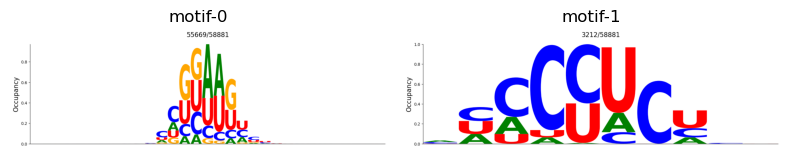

⏱ 0.30 s (00:00:00)


In [97]:
# ── Display consensus motif logos ──────────────────────────────────────────────
from PIL import Image

motif_pngs = sorted(_motifs_out_dir.glob("motif-*.png"))
fig, axes = plt.subplots(1, len(motif_pngs), figsize=(4 * len(motif_pngs), 3))
if len(motif_pngs) == 1:
    axes = [axes]
for ax, png in zip(axes, motif_pngs):
    ax.imshow(Image.open(png))
    ax.set_title(png.stem)
    ax.axis("off")
plt.tight_layout()
_run_label = EVAL_RUN.split(".globalclip")[0]  # e.g. "parnet.21m-0.0.unfreeze_last_2_layers"
plt.savefig(FILEPATHS["figures_dir"] / f"consensus_motifs.{_run_label}.png", dpi=150, bbox_inches="tight")
plt.show()

In [99]:
# ── Load consensus motif PPMs ──────────────────────────────────────────────────
def load_consensus_ppm(tsv_path):
    """Load a metamotif consensus motif TSV into a (L, 4) PPM array.
    Format: first line is '#support=N', then header 'A C G U', then rows.
    Columns are A, C, G, U (RNA) — we map U→T for matching against DNA PPMs.
    """
    df = pd.read_csv(tsv_path, sep="\t", comment="#")
    # columns are A, C, G, U → treat U as T
    mat = df[["A", "C", "G", "U"]].to_numpy(dtype=float)
    row_sums = mat.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return mat / row_sums

consensus_motifs = {}
for tsv in sorted(_motifs_out_dir.glob("motif-*.tsv")):
    consensus_motifs[tsv.stem] = load_consensus_ppm(tsv)
    logger.info(f"{tsv.stem}: PPM shape {consensus_motifs[tsv.stem].shape}")

[19:25:46] INFO - motif-0: PPM shape (31, 4)
[19:25:46] INFO - motif-1: PPM shape (10, 4)


⏱ 0.01 s (00:00:00)


In [5]:
# ── Match consensus motifs against RBP database ────────────────────────────────
def best_pcc(query_ppm, target_ppm, min_overlap_frac=0.8):
    """Best sliding-window PCC between two PPMs of shape (L, 4).
    Requires overlap to be at least min_overlap_frac of the shorter motif,
    so a tiny window of a long motif can't score a lucky perfect match.
    """
    L1, L2 = len(query_ppm), len(target_ppm)
    required_overlap = int(np.ceil(min_overlap_frac * min(L1, L2)))
    best = -np.inf
    for shift in range(-(L2 - required_overlap), L1 - required_overlap + 1):
        s1 = max(0, shift)
        e1 = min(L1, shift + L2)
        s2 = s1 - shift
        e2 = s2 + (e1 - s1)
        if e1 - s1 < required_overlap:
            continue
        a = query_ppm[s1:e1].flatten()
        b = target_ppm[s2:e2].flatten()
        if a.std() == 0 or b.std() == 0:
            continue
        r, _ = pearsonr(a, b)
        if np.isfinite(r):
            best = max(best, r)
    return best if best > -np.inf else np.nan

# match each consensus motif against all RBPs
match_results = {}
for motif_name, query_ppm in consensus_motifs.items():
    rbp_best = {}
    for rbp, motif_list in all_motifs.items():
        best = max((best_pcc(query_ppm, m) for m in motif_list), default=np.nan)
        if np.isfinite(best):
            rbp_best[rbp] = best
    top_rbps = sorted(rbp_best.items(), key=lambda x: x[1], reverse=True)[:10]
    match_results[motif_name] = top_rbps

# print results
for motif_name, top_rbps in match_results.items():
    print(f"\n{motif_name} → top matching RBPs:")
    for rbp, score in top_rbps:
        print(f"   {rbp:15s}  PCC={score:.3f}")

NameError: name 'consensus_motifs' is not defined

⏱ 0.18 s (00:00:00)


In [103]:
# ── Inspect information content per motif ──────────────────────────────────────
def information_content(ppm):
    """Per-position information content (bits) of a (L, 4) PPM."""
    with np.errstate(divide="ignore", invalid="ignore"):
        entropy = -np.nansum(ppm * np.log2(ppm + 1e-10), axis=1)
    return 2.0 - entropy

for name, ppm in consensus_motifs.items():
    ic = information_content(ppm)
    print(f"\n{name} (len {len(ppm)}):")
    print(f"  IC per position: {np.round(ic, 2)}")
    print(f"  min={ic.min():.2f}, max={ic.max():.2f}, mean={ic.mean():.2f}")


motif-0 (len 31):
  IC per position: [2.   2.   2.   1.   0.5  0.5  0.34 0.44 0.21 0.15 0.61 0.25 0.12 0.23
 0.13 0.4  0.46 0.29 0.23 0.23 0.53 0.33 0.11 0.16 0.24 0.85 0.54 1.08
 1.08 1.   2.  ]
  min=0.11, max=2.00, mean=0.65

motif-1 (len 10):
  IC per position: [0.81 0.43 0.64 1.28 0.97 0.79 1.99 0.55 2.   2.  ]
  min=0.43, max=2.00, mean=1.15
⏱ 0.00 s (00:00:00)


In [107]:
# ── Save motif → RBP matches ───────────────────────────────────────────────────
import json

match_out = {
    motif: [{"rbp": rbp, "pcc": round(float(score), 4)} for rbp, score in top_rbps]
    for motif, top_rbps in match_results.items()
}

_match_path = METAMOTIF_DIR / "rbp_matches.json"
_match_path.write_text(json.dumps(match_out, indent=2))
logger.info(f"Saved RBP matches → {_match_path}")

[19:27:38] INFO - Saved RBP matches → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/rbp_matches.json


⏱ 0.03 s (00:00:00)


In [9]:
# ── Re-run RBP matching (mCrossBase only) for all 4 models ─────────────────────
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import pearsonr
import json

MIN_OVERLAP = 4

MOTIF_COMPARISON_RUNS = {
    "head (7M)":        "parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50",
    "unfreeze_2 (7M)":  "parnet.7m-0.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50",
    "unfreeze_5 (7M)":  "parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50",
    "unfreeze_2 (21M)": "parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50",
}

RUNS_DIR = PROJECT_DIR / "results" / "globalclip-head" / "training"

# ── Load RBP motifs (mCrossBase only) ───────────────────────────────────────────
import pylbsr.bio.motifs as motifs_lib
from pylbsr.bio.motifs.motif import convert_matrix_type

MOTIFS_DIR = Path("/mnt/storage1/ml4rg26-shared/rbp_binding_motifs")
DATABASES = ["mCrossBase"]  # restricted for this robustness check

def load_motif_ppm(f):
    with open(f) as fh:
        ms = motifs_lib.read_motifs_transfac(fh)
    if not ms:
        return None
    m = ms[0]
    mt = f.stem.split(".")[1].upper()
    m.matrix_type = mt
    try:
        if mt in ("PCM", "PPM"):
            m = convert_matrix_type(m, "PPM")
        else:
            return None
    except Exception:
        return None
    return m

all_motifs = {}
for db in DATABASES:
    preproc = MOTIFS_DIR / db / "preprocessed"
    if not preproc.exists():
        continue
    for rbp_dir in preproc.iterdir():
        if not rbp_dir.is_dir():
            continue
        rbp = rbp_dir.name
        for f in rbp_dir.glob("*.transfac"):
            m = load_motif_ppm(f)
            if m is None:
                continue
            all_motifs.setdefault(rbp, []).append(m.matrix.to_numpy(dtype=float))

logger.info(f"Loaded motifs for {len(all_motifs)} RBPs from {DATABASES}")

# ── Matching function ────────────────────────────────────────────────────────
def best_pcc(query_ppm, target_ppm, min_overlap_frac=0.8):
    L1, L2 = len(query_ppm), len(target_ppm)
    required_overlap = int(np.ceil(min_overlap_frac * min(L1, L2)))
    best = -np.inf
    for shift in range(-(L2 - required_overlap), L1 - required_overlap + 1):
        s1 = max(0, shift)
        e1 = min(L1, shift + L2)
        s2 = s1 - shift
        e2 = s2 + (e1 - s1)
        if e1 - s1 < required_overlap:
            continue
        a = query_ppm[s1:e1].flatten()
        b = target_ppm[s2:e2].flatten()
        if a.std() == 0 or b.std() == 0:
            continue
        r, _ = pearsonr(a, b)
        if np.isfinite(r):
            best = max(best, r)
    return best if best > -np.inf else np.nan

def load_consensus_ppm(tsv_path):
    df = pd.read_csv(tsv_path, sep="\t", comment="#")
    mat = df[["A", "C", "G", "U"]].to_numpy(dtype=float)
    row_sums = mat.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return mat / row_sums

# ── Loop over all 4 models ──────────────────────────────────────────────────────
mcross_only_results = {}
for label, run in MOTIF_COMPARISON_RUNS.items():
    motif_dir = RUNS_DIR / run / "integrated_gradients" / "metamotif" / "aligned_motifs"
    tsvs = sorted(motif_dir.glob("motif-*.tsv"))
    for tsv in tsvs:
        motif_name = tsv.stem
        query_ppm = load_consensus_ppm(tsv)
        rbp_best = {}
        for rbp, motif_list in all_motifs.items():
            best = max((best_pcc(query_ppm, m) for m in motif_list), default=np.nan)
            if np.isfinite(best):
                rbp_best[rbp] = best
        top_rbps = sorted(rbp_best.items(), key=lambda x: x[1], reverse=True)[:3]
        mcross_only_results[f"{label} | {motif_name}"] = top_rbps
        print(f"{label} | {motif_name} → {top_rbps}")

# ── Save results ────────────────────────────────────────────────────────────────
_out = {k: [{"rbp": r, "pcc": round(float(s), 4)} for r, s in v] for k, v in mcross_only_results.items()}
_out_path = RUNS_DIR.parent / "mcross_only_rbp_matches.json"
_out_path.write_text(json.dumps(_out, indent=2))
logger.info(f"Saved → {_out_path}")

[14:33:34] INFO - Loaded motifs for 103 RBPs from ['mCrossBase']


head (7M) | motif-0 → [('PRPF8', 0.7616854280845314), ('GPKOW', 0.7302835522148357), ('EFTUD2', 0.7095094216282852)]
head (7M) | motif-1 → [('ILF3', 0.8048682319524986), ('PCBP2', 0.8041544951031911), ('HNRNPK', 0.8007902007044014)]
head (7M) | motif-2 → [('RBM22', 0.7343976446929011), ('SUGP2', 0.7183804986473709), ('PTBP1', 0.6953544895513617)]
unfreeze_2 (7M) | motif-0 → [('LARP7', 0.7432155876893061), ('ILF3', 0.7046309419425975), ('FASTKD2', 0.6664049110172309)]
unfreeze_2 (7M) | motif-1 → [('GPKOW', 0.8332274655647979), ('BUD13', 0.8287887917721397), ('PRPF8', 0.818487633506316)]
unfreeze_2 (7M) | motif-2 → [('PPIG', 0.8703807451925073), ('BUD13', 0.8327452637265979), ('PRPF8', 0.8260816676104202)]
unfreeze_5 (7M) | motif-0 → [('AGGF1', 0.7818390428773896), ('KHDRBS1', 0.7146819353271165), ('LARP7', 0.6845268466046688)]
unfreeze_5 (7M) | motif-1 → [('NPM1', 0.83816608305308), ('TRA2A', 0.7850496062528367), ('CPSF6', 0.7616146648485546)]
unfreeze_5 (7M) | motif-2 → [('DDX55', 0.69

[14:34:33] INFO - Saved → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/mcross_only_rbp_matches.json


unfreeze_2 (21M) | motif-1 → [('ILF3', 0.831304672487682), ('DDX59', 0.830373729431915), ('HNRNPK', 0.8248831788757784)]
⏱ 66.99 s (00:01:06)


In [6]:
# ── Match consensus motifs against RBP database ────────────────────────────────
def best_pcc(query_ppm, target_ppm, min_overlap_frac=0.8):
    """Best sliding-window PCC between two PPMs of shape (L, 4).
    Requires overlap to be at least min_overlap_frac of the shorter motif,
    so a tiny window of a long motif can't score a lucky perfect match.
    """
    L1, L2 = len(query_ppm), len(target_ppm)
    required_overlap = int(np.ceil(min_overlap_frac * min(L1, L2)))
    best = -np.inf
    for shift in range(-(L2 - required_overlap), L1 - required_overlap + 1):
        s1 = max(0, shift)
        e1 = min(L1, shift + L2)
        s2 = s1 - shift
        e2 = s2 + (e1 - s1)
        if e1 - s1 < required_overlap:
            continue
        a = query_ppm[s1:e1].flatten()
        b = target_ppm[s2:e2].flatten()
        if a.std() == 0 or b.std() == 0:
            continue
        r, _ = pearsonr(a, b)
        if np.isfinite(r):
            best = max(best, r)
    return best if best > -np.inf else np.nan


# ── Check PTBP1 vs Idea 1's top-5 RBP motifs ────────────────────────────────
idea1_top5 = ["SND1", "YBX3", "PABPN1", "SRSF1", "LIN28B"]

ptbp1_motifs = all_motifs.get("PTBP1", [])
if not ptbp1_motifs:
    print("PTBP1 not found in loaded motif set — check DATABASES includes its source")

for rbp in idea1_top5:
    other_motifs = all_motifs.get(rbp, [])
    if not other_motifs:
        print(f"{rbp}: not found in loaded databases")
        continue
    best = max(
        (best_pcc(m1, m2) for m1 in ptbp1_motifs for m2 in other_motifs),
        default=np.nan,
    )
    print(f"PTBP1 vs {rbp}: best PCC = {best:.3f}")

PTBP1 vs SND1: best PCC = 0.980
PTBP1 vs YBX3: best PCC = 0.745
PTBP1 vs PABPN1: best PCC = 0.700
PTBP1 vs SRSF1: best PCC = 0.907
PTBP1 vs LIN28B: best PCC = 0.736
⏱ 12.99 s (00:00:12)


In [10]:
# ── Find the Idea 1 example window in our dataset ──────────────────────────────
import torch

TARGET_COORD = "chr8:27610416-27611016"  # minus strand

data = torch.load(FILEPATHS.data, mmap=True, weights_only=False)  # or raw path if needed

found = None
for split in ["train", "valid", "test"]:
    for i, s in enumerate(data[split]):
        name = s["meta"]["name"]
        if "27610416" in name or "27611016" in name:
            print(f"Found in {split}[{i}]: {name}")
            found = (split, i, s)

if found is None:
    print("Window not found in any split — may use different coordinate convention or padding")

Found in test[3869]: chr8:27610416-27611016:-
⏱ 9.70 s (00:00:09)


In [18]:
# ── Load the specific window and run model + IG ────────────────────────────────
sample = data["test"][3869]

# get sequence and convert to one-hot tensor for the model
from parnet_demo_utils import torch_sparse_to_dense

seq_str = sample["inputs"]["sequence"]
target_dense = torch_sparse_to_dense(sample["outputs"]["globalCLIP"])  # (1, 600)

print(f"Window: {sample['meta']['name']}")
print(f"Sequence length: {len(seq_str)}")
print(f"Total signal: {target_dense.sum().item():.1f}")

# one-hot encode the sequence (A, C, G, T)
NUCLEOTIDE_ARR = np.array(["A", "C", "G", "T"])
def string_to_onehot(seq_str):
    onehot = np.zeros((4, len(seq_str)), dtype=np.float32)
    for i, base in enumerate(seq_str):
        idx = np.where(NUCLEOTIDE_ARR == base)[0]
        if len(idx) > 0:
            onehot[idx[0], i] = 1.0
    return onehot

seq_onehot = string_to_onehot(seq_str)
sequence = torch.tensor(seq_onehot).unsqueeze(0).to(device)  # (1, 4, 600)

# run model prediction
model.eval()
with torch.no_grad():
    y_pred = model(sequence=sequence)["total"].squeeze().cpu().numpy()

# run IG
attrs = integrated_gradients(model, sequence, n_steps=params_n_steps)  # (4, 600)
importance = attrs.sum(axis=0)  # per-position importance

print(f"Predicted signal (log-prob) range: {y_pred.min():.3f} to {y_pred.max():.3f}")

Window: chr8:27610416-27611016:-
Sequence length: 600
Total signal: 945.0
Predicted signal (log-prob) range: -13.022 to -2.654
⏱ 0.42 s (00:00:00)


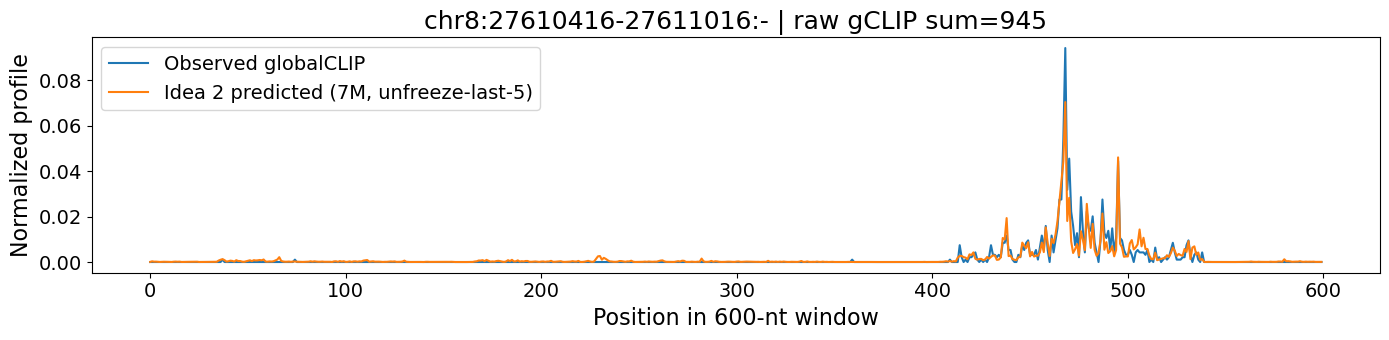

⏱ 0.25 s (00:00:00)


In [25]:
# ── Plot predicted vs observed signal (matching Idea 1's style) ────────────────
import matplotlib.pyplot as plt

# convert log-prob prediction to a normalized profile for visual comparison
pred_prob = np.exp(y_pred)  # convert log-prob back to probability
pred_prob = pred_prob / pred_prob.sum()  # ensure normalized

target_prob = target_dense.squeeze().numpy()
target_prob = target_prob / target_prob.sum()  # normalize observed too

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(target_prob, label="Observed globalCLIP", color="tab:blue", linewidth=1.5)
ax.plot(pred_prob, label="Idea 2 predicted (7M, unfreeze-last-5)", color="tab:orange", linewidth=1.5)
ax.set_xlabel("Position in 600-nt window", fontsize=16)
ax.set_ylabel("Normalized profile", fontsize=16)
ax.set_title(f"chr8:27610416-27611016:- | raw gCLIP sum=945", fontsize=18)
ax.tick_params(axis='both', labelsize=14)
ax.legend(fontsize=14)
plt.tight_layout()
plt.savefig(FILEPATHS["figures_dir"] / "idea2_example_window_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Highest-attribution region: position 395 to 495


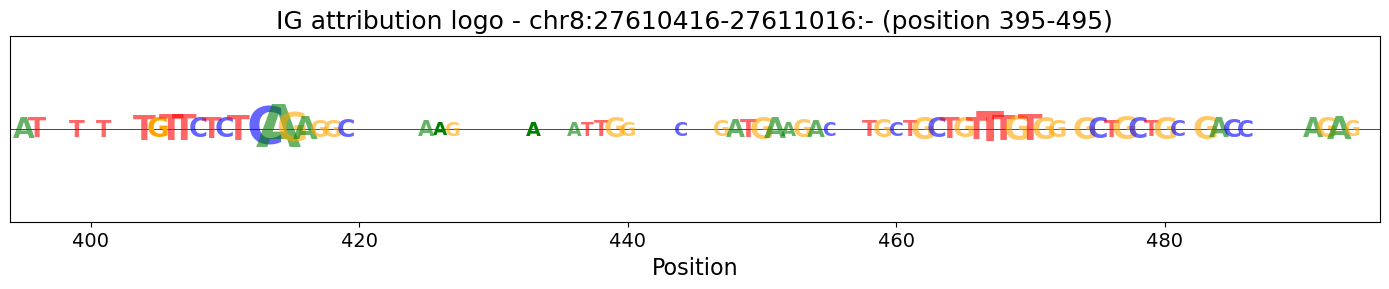

⏱ 0.27 s (00:00:00)


In [30]:
# ── Find the high-attribution region and zoom in ────────────────────────────────
# find the window of highest cumulative importance (e.g. best 100nt stretch)

# ── Attribution logo plotting function ──────────────────────────────────────────
NUCLEOTIDES = ["A", "C", "G", "T"]
COLORS = {"A": "green", "C": "blue", "G": "orange", "T": "red"}

def plot_attribution_logo(attributions, sequence, start=0, end=100, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(20, 3))

    max_score = np.abs(attributions[:, start:end]).max()

    for pos in range(start, end):
        for nuc_idx, nuc in enumerate(NUCLEOTIDES):
            if sequence[nuc_idx, pos] == 0:
                continue
            score = attributions[nuc_idx, pos]
            if abs(score) < 0.1 * max_score:
                continue
            fontsize = 10 + (abs(score) / max_score) * 32  # bumped base + scaling
            color = COLORS[nuc]
            alpha = 1.0 if score > 0 else 0.6
            ax.text(
                pos, 0, nuc,
                fontsize=fontsize,
                color=color,
                alpha=alpha,
                ha="center", va="center",
                fontweight="bold",
            )

    ax.set_xlim(start - 1, end + 1)
    ax.set_ylim(-1, 1)
    ax.set_xlabel("Position", fontsize=16)
    ax.tick_params(axis='both', labelsize=14)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_yticks([])
    return ax

window_size = 100
cumsum = np.convolve(np.abs(importance), np.ones(window_size), mode='valid')
best_start = np.argmax(cumsum)
best_end = best_start + window_size

print(f"Highest-attribution region: position {best_start} to {best_end}")

# reuse your attribution logo plotting function from earlier in the notebook
fig, ax = plt.subplots(figsize=(14, 3))
plot_attribution_logo(attrs, seq_onehot, start=best_start, end=best_end, ax=ax)
ax.set_title(f"IG attribution logo - chr8:27610416-27611016:- (position {best_start}-{best_end})", fontsize=18)
plt.tight_layout()
plt.savefig(FILEPATHS["figures_dir"] / "idea2_example_window_logo_zoom.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
# ── Inspect nucleotide composition of PTBP1 and Idea 1's top-5 RBP motifs ──────
idea1_top5 = ["SND1", "YBX3", "PABPN1", "SRSF1", "LIN28B"]
rbps_to_check = ["PTBP1"] + idea1_top5

for rbp in rbps_to_check:
    motifs = all_motifs.get(rbp, [])
    if not motifs:
        print(f"{rbp}: not found")
        continue
    # average composition across all motif variants for this RBP
    avg_comp = np.mean([m.mean(axis=0) for m in motifs], axis=0)  # (4,) - A, C, G, T
    print(f"{rbp}: A={avg_comp[0]:.2f} C={avg_comp[1]:.2f} G={avg_comp[2]:.2f} T={avg_comp[3]:.2f}  "
          f"(pyrimidine C+T = {avg_comp[1]+avg_comp[3]:.2f})")

PTBP1: A=0.03 C=0.35 G=0.04 T=0.58  (pyrimidine C+T = 0.93)
SND1: A=0.21 C=0.29 G=0.22 T=0.27  (pyrimidine C+T = 0.57)
YBX3: A=0.28 C=0.36 G=0.11 T=0.24  (pyrimidine C+T = 0.60)
PABPN1: A=0.63 C=0.07 G=0.26 T=0.04  (pyrimidine C+T = 0.11)
SRSF1: A=0.36 C=0.17 G=0.38 T=0.09  (pyrimidine C+T = 0.25)
LIN28B: A=0.30 C=0.11 G=0.28 T=0.31  (pyrimidine C+T = 0.42)
⏱ 0.00 s (00:00:00)
